<a target="_blank" href="https://colab.research.google.com/github/lukebarousse/Python_Data_Analytics_Course/blob/main/4_Problems/2_15_Matplotlib Scatter Plots.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## 🟨 Median Yearly Salary vs. Job Count (2.15.1)

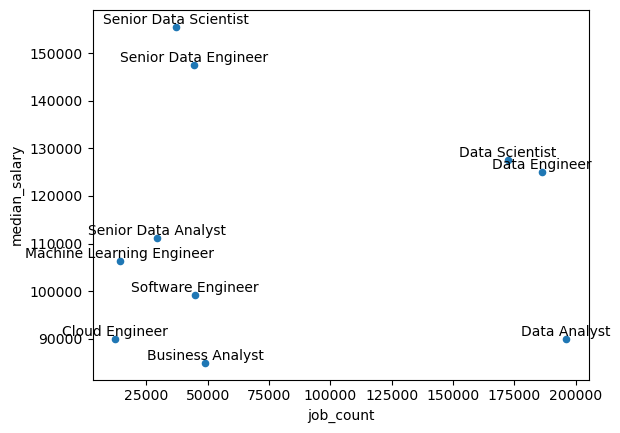

In [21]:
new_df = df.copy()
new_df = new_df.groupby('job_title_short').agg(
    median_salary=('salary_year_avg', 'median'),
    job_count=('job_title_short', 'size')
)
new_df.sort_values('median_salary', ascending=False)
new_df.plot(kind='scatter', x='job_count', y='median_salary')

# for i, txt in enumerate(new_df.index):
#     plt.text(new_df['job_count'].iloc[i], new_df['median_salary'].iloc[i], txt)

# plt.tight_layout()
# plt.show()
for i in range(len(new_df)):
   job_count = new_df['job_count'].iloc[i]
   mean_salary = new_df['median_salary'].iloc[i]
   job_title = new_df.index[i]
   plt.text(job_count, mean_salary, job_title, ha='center', va='bottom')

plt.show()

---

## 🟨 Top 7 Countries by Median Yearly Salary vs Job Count  (2.15.2)

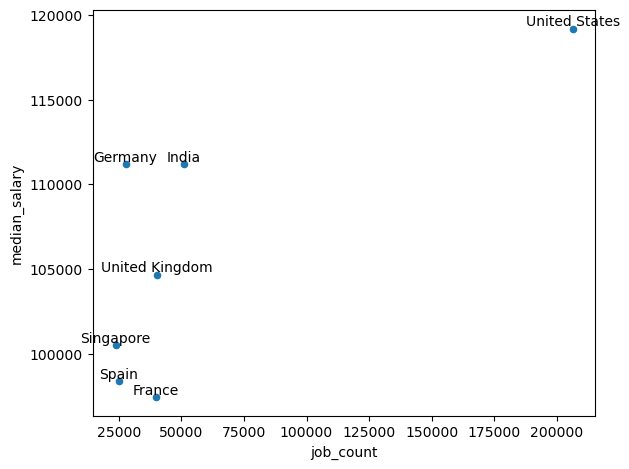

In [20]:
new_df = df.copy()
new_df = new_df.groupby('job_country').agg(
    median_salary=('salary_year_avg', 'median'),
    job_count=('job_title_short', 'size')
)
new_df_sorted = new_df.sort_values('job_count', ascending=False).head(7)
new_df_sorted.plot(kind='scatter', x='job_count', y='median_salary')

# for i, txt in enumerate(new_df_sorted.index):
#     plt.text(new_df_sorted['job_count'].iloc[i], new_df_sorted['median_salary'].iloc[i], txt)
for i in range(len(new_df_sorted)):
   job_count = new_df_sorted['job_count'].iloc[i]
   mean_salary = new_df_sorted['median_salary'].iloc[i]
   job_title = new_df_sorted.index[i]
   plt.text(job_count, mean_salary, job_title, ha='center', va='bottom')
plt.tight_layout()
plt.show()

---

## 🟥 Average Yearly Salary vs. Job Count for Top Roles by Schedule Type (2.15.3)

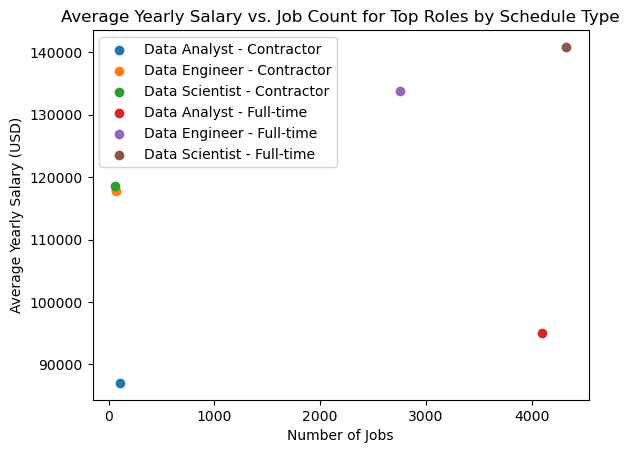

In [ ]:
# Code Needed
target_job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']
us_jobs_df = df[
   (df['job_country'] == 'United States') &
   (df['job_schedule_type'].isin(['Full-time', 'Contractor'])) &
   (df['job_title_short'].isin(target_job_titles))
].dropna(subset=['salary_year_avg']).copy()

stats = us_jobs_df.groupby(['job_schedule_type', 'job_title_short']).agg(
   mean_salary_year_avg=('salary_year_avg', 'mean'),
   job_count=('job_title_short', 'count')
).dropna()

stats.reset_index(inplace=True)

# Combine title and type into one value for labels
stats['job_title_type'] = stats['job_title_short'] + ' - ' + stats['job_schedule_type']

for job_title_type in stats['job_title_type'].unique():
   subset = stats[stats['job_title_type'] == job_title_type]
   plt.scatter(subset['job_count'], subset['mean_salary_year_avg'], label=job_title_type)

plt.xlabel('Number of Jobs')
plt.ylabel('Average Yearly Salary (USD)')
plt.title('Average Yearly Salary vs. Job Count for Top Roles by Schedule Type')
plt.legend()
plt.show()

---